In [2]:
%matplotlib inline

import mne
from mne.datasets import eegbci
import numpy as np
import matplotlib.pyplot as plt
import os

mne.set_log_level('WARNING')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if 'notebooks' in os.getcwd() else os.getcwd()
RESULTS_DIR = os.path.join(REPO_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Results dir: {RESULTS_DIR}")

subject = 1
runs = [6, 10]
raw_files = eegbci.load_data(subject, runs)
raw = mne.concatenate_raws([mne.io.read_raw_edf(f, preload=True) for f in raw_files])

Repo root: C:\Various\Personal\Projects\neuro-decode
Results dir: C:\Various\Personal\Projects\neuro-decode\results


In [3]:
#filter frequencies under 8 Hz and over 30 Hz
raw_filtered = raw.copy().filter(l_freq=8., h_freq=30.)

print("Filter used: 8–30 Hz")
print(raw_filtered.info)

Filter used: 8–30 Hz
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 8.0 Hz
 lowpass: 30.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


C:\Users\ameli\AppData\Local\Temp\ipykernel_57676\1521054725.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot(axes=axes[0], show=False)
C:\Users\ameli\AppData\Local\Temp\ipykernel_57676\1521054725.py:6: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_filtered.compute_psd(fmax=80).plot(axes=axes[1], show=False)


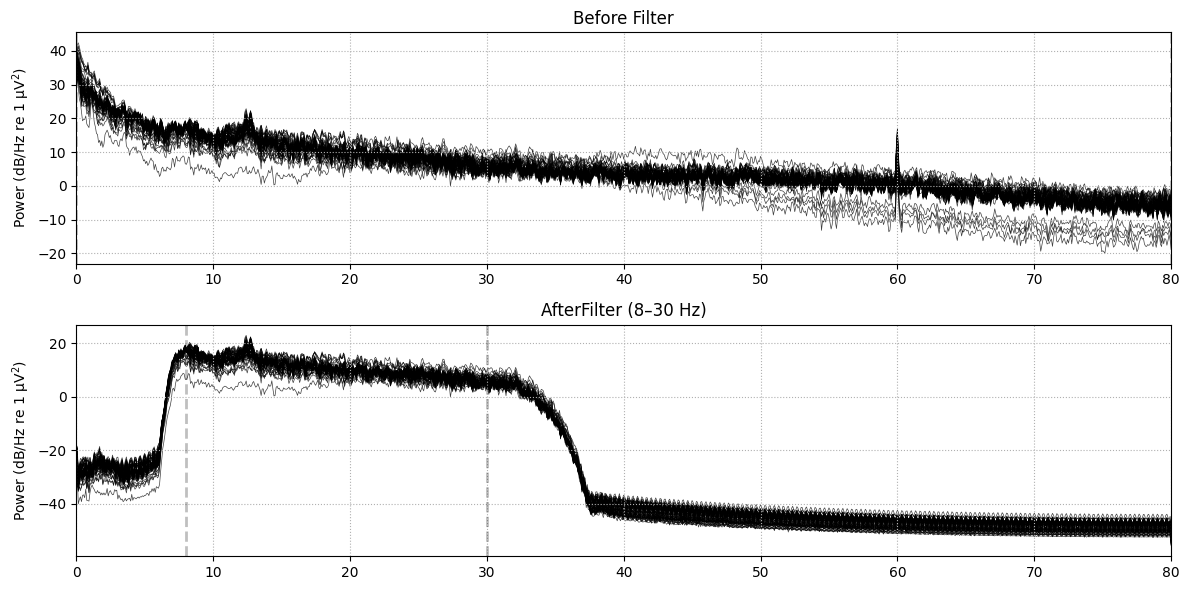

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

raw.compute_psd(fmax=80).plot(axes=axes[0], show=False)
axes[0].set_title('Before Filter')

raw_filtered.compute_psd(fmax=80).plot(axes=axes[1], show=False)
axes[1].set_title('AfterFilter (8–30 Hz)')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_filter_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [5]:
#extract events from annotations
events, event_id = mne.events_from_annotations(raw_filtered)

#only select T1 and T2
event_id_selected = {'T1': 2, 'T2': 3}

#cut epochs (0-4 seconds after every event)
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id=event_id_selected,
    tmin=0.0,
    tmax=4.0,
    baseline=None,
    preload=True
)

print(epochs)
print(f"\nAnzahl Epochen: {len(epochs)}")
print(f"Epochen pro Klasse: {epochs.event_id}")

<Epochs | 30 events (all good), 0 – 4 s (baseline off), ~9.4 MiB, data loaded,
 'T1': 14
 'T2': 16>

Anzahl Epochen: 30
Epochen pro Klasse: {'T1': 2, 'T2': 3}


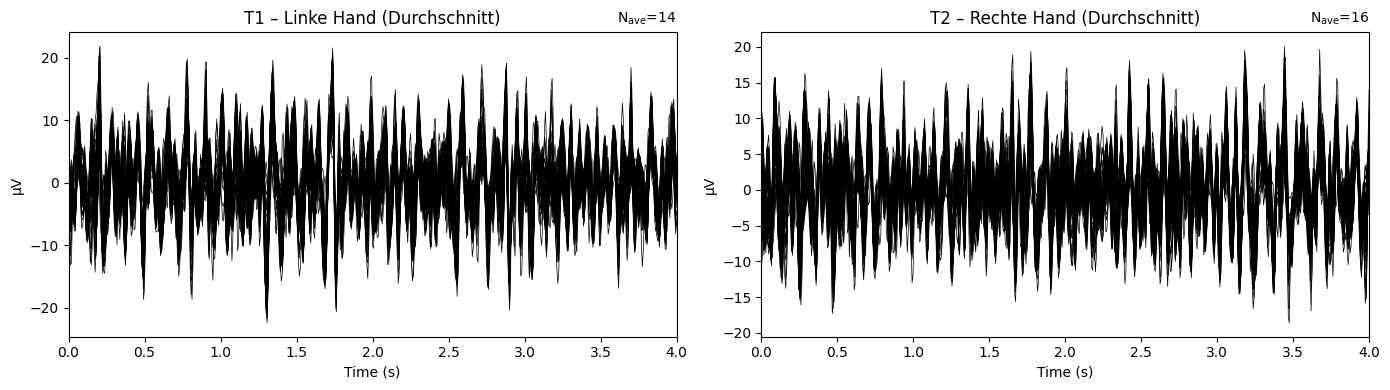

In [6]:
#plot the average signal per class (Event-Related Potential)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs['T1'].average().plot(axes=axes[0], show=False)
axes[0].set_title('T1 – Left Hand (Average)')

epochs['T2'].average().plot(axes=axes[1], show=False)
axes[1].set_title('T2 – Right Hand (Average)')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_epochs_average.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [8]:
# Data als NumPy Array – Shape: (n_epochs, n_channels, n_timepoints)
X = epochs.get_data()
y = epochs.events[:, 2]  # Labels: 2 = T1, 3 = T2

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Labels: {np.unique(y)}")

X shape: (30, 64, 641)
y shape: (30,)
Labels: [2 3]
